# SO-101 인형 Pick & Place ACT 모델 검증

최종 `020000` 체크포인트를 실제 로봇을 움직이지 않고 검증합니다.

- 체크포인트·전처리기·학습 상태 파일 무결성
- 20,000 step 학습 곡선과 최종 loss
- 100개 에피소드 데이터 및 카메라 샘플
- 학습 데이터 표본에서 ACT action chunk 예측과 정답 비교
- 관절별 MAE/RMSE, 학습 범위 이탈률, 예측 궤적 시각화

> **해석 주의:** 현재 100개 에피소드 전부를 학습에 사용했으므로 이 결과는 학습 데이터 재현 성능(in-sample sanity check)입니다. 새 배치·새 물체 위치에 대한 일반화 성능은 별도 미사용 에피소드 또는 실제 로봇 저속 시험으로 확인해야 합니다.

In [1]:
from pathlib import Path
import json, re, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

%matplotlib inline
warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']

ROOT = Path(r'D:\lerobot-2026')
WORK_DIR = ROOT / 'episode_sample_dataset' / 'doll_pickplace_act'
DATASET_ROOT = ROOT / 'episode_sample_dataset' / 'auto_home_collection' / 'auto_home_dataset'
CHECKPOINT_DIR = WORK_DIR / 'outputs' / 'act_100ep_20k' / 'checkpoints' / '020000'
MODEL_DIR = CHECKPOINT_DIR / 'pretrained_model'
OUTPUT_DIR = WORK_DIR / 'validation_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
JOINTS = ['shoulder_pan', 'shoulder_lift', 'elbow_flex', 'wrist_flex', 'wrist_roll', 'gripper']
print(f'Device: {DEVICE}' + (f' ({torch.cuda.get_device_name(0)})' if DEVICE.type == 'cuda' else ''))
print(f'Model:  {MODEL_DIR}')

Device: cuda (NVIDIA GeForce RTX 3080)
Model:  D:\lerobot-2026\episode_sample_dataset\doll_pickplace_act\outputs\act_100ep_20k\checkpoints\020000\pretrained_model


## 1. 체크포인트 무결성

In [2]:
required = [
    MODEL_DIR / 'config.json',
    MODEL_DIR / 'model.safetensors',
    MODEL_DIR / 'policy_preprocessor.json',
    MODEL_DIR / 'policy_preprocessor_step_3_normalizer_processor.safetensors',
    MODEL_DIR / 'policy_postprocessor.json',
    MODEL_DIR / 'policy_postprocessor_step_0_unnormalizer_processor.safetensors',
    MODEL_DIR / 'train_config.json',
    CHECKPOINT_DIR / 'training_state' / 'optimizer_state.safetensors',
]
artifact_rows = []
for p in required:
    artifact_rows.append({'artifact': str(p.relative_to(CHECKPOINT_DIR)), 'exists': p.is_file(), 'size_MB': round(p.stat().st_size / 2**20, 3) if p.is_file() else 0})
artifacts = pd.DataFrame(artifact_rows)
display(artifacts)
assert artifacts['exists'].all(), '필수 체크포인트 파일이 누락되었습니다.'
with open(MODEL_DIR / 'config.json', encoding='utf-8') as f:
    model_cfg = json.load(f)
print('Checkpoint integrity: PASS')
print('Inputs :', ', '.join(model_cfg['input_features']))
print('Output :', ', '.join(model_cfg['output_features']))
print('Chunk  :', model_cfg['chunk_size'], 'frames')
print('Depth  : 학습 입력에서 제외됨 (원본 데이터에는 보존)')

,artifact,exists,size_MB
0,pretrained_model\config.json,True,0.002
1,pretrained_model\model.safetensors,True,197.124
2,pretrained_model\policy_preprocessor.json,True,0.001
3,pretrained_model\policy_preprocessor_step_3_no...,True,0.008
4,pretrained_model\policy_postprocessor.json,True,0.001
5,pretrained_model\policy_postprocessor_step_0_u...,True,0.008
6,pretrained_model\train_config.json,True,0.006
7,training_state\optimizer_state.safetensors,True,393.694


Checkpoint integrity: PASS
Inputs : observation.state, observation.images.top, observation.images.side
Output : action
Chunk  : 100 frames
Depth  : 학습 입력에서 제외됨 (원본 데이터에는 보존)


## 2. 학습 곡선

,loss,l1_loss,kld_loss,step
995,0.191,0.162,0.003,19920
996,0.190,0.161,0.003,19940
997,0.183,0.150,0.003,19960
998,0.204,0.173,0.003,19980
999,0.198,0.167,0.003,20000


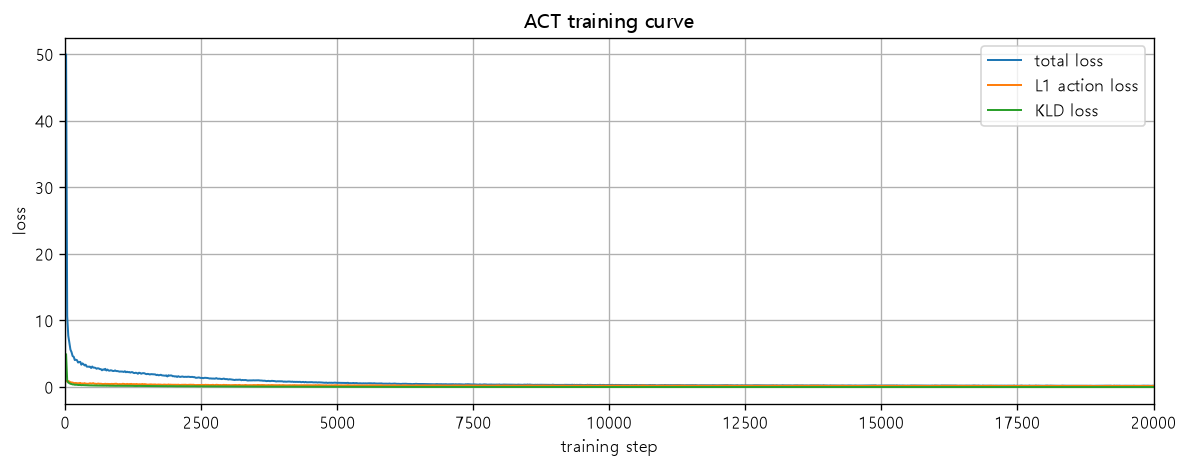

초기 10% 중앙 loss: 2.3545
후기 10% 중앙 loss: 0.1980
감소율: 91.6%
로그 최종 loss: 0.1980


In [3]:
log_paths = [WORK_DIR / 'train_stderr.log', WORK_DIR / 'train_resume_stderr.log']
pattern = re.compile(r'loss:([0-9.]+).*?l1_loss:([0-9.]+).*?kld_loss:([0-9.]+)')
records = []
for log_path in log_paths:
    if not log_path.exists():
        continue
    for line in log_path.read_text(encoding='utf-8', errors='ignore').splitlines():
        m = pattern.search(line)
        if m:
            records.append(tuple(map(float, m.groups())))
train_curve = pd.DataFrame(records, columns=['loss', 'l1_loss', 'kld_loss'])
train_curve['step'] = (np.arange(len(train_curve)) + 1) * 20
train_curve = train_curve[train_curve['step'] <= 20000]
display(train_curve.tail())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_curve['step'], train_curve['loss'], label='total loss', linewidth=1.2)
ax.plot(train_curve['step'], train_curve['l1_loss'], label='L1 action loss', linewidth=1.2)
ax.plot(train_curve['step'], train_curve['kld_loss'], label='KLD loss', linewidth=1.2)
ax.set(title='ACT training curve', xlabel='training step', ylabel='loss', xlim=(0, 20000))
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_curve.png', bbox_inches='tight')
plt.show()

first_window = train_curve.head(max(1, len(train_curve)//10))['loss'].median()
last_window = train_curve.tail(max(1, len(train_curve)//10))['loss'].median()
print(f'초기 10% 중앙 loss: {first_window:.4f}')
print(f'후기 10% 중앙 loss: {last_window:.4f}')
print(f'감소율: {(1-last_window/first_window)*100:.1f}%')
print(f'로그 최종 loss: {train_curve.iloc[-1].loss:.4f}')

## 3. 데이터셋과 최종 모델 로드

In [4]:
from lerobot.policies.act import ACTConfig, ACTPolicy  # ACTConfig import가 레지스트리를 등록함
from lerobot.configs.train import TrainPipelineConfig
from lerobot.datasets.factory import make_dataset
from lerobot.policies import make_pre_post_processors

train_cfg = TrainPipelineConfig.from_pretrained(MODEL_DIR)
dataset = make_dataset(train_cfg)
assert dataset.num_episodes == 100 and len(dataset) == 56768

policy = ACTPolicy.from_pretrained(MODEL_DIR).to(DEVICE).eval()
preprocess, postprocess = make_pre_post_processors(policy.config, pretrained_path=str(MODEL_DIR))

print(f'Dataset: {dataset.num_episodes} episodes, {len(dataset):,} frames, {dataset.fps} fps')
print(f'Policy parameters: {sum(p.numel() for p in policy.parameters()):,}')
print('Model load and processor load: PASS')

D:\lerobot-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights from local directory

Dataset: 100 episodes, 56,768 frames, 30 fps

Policy parameters: 51,597,190

Model load and processor load: PASS

## 4. 카메라 입력 표본

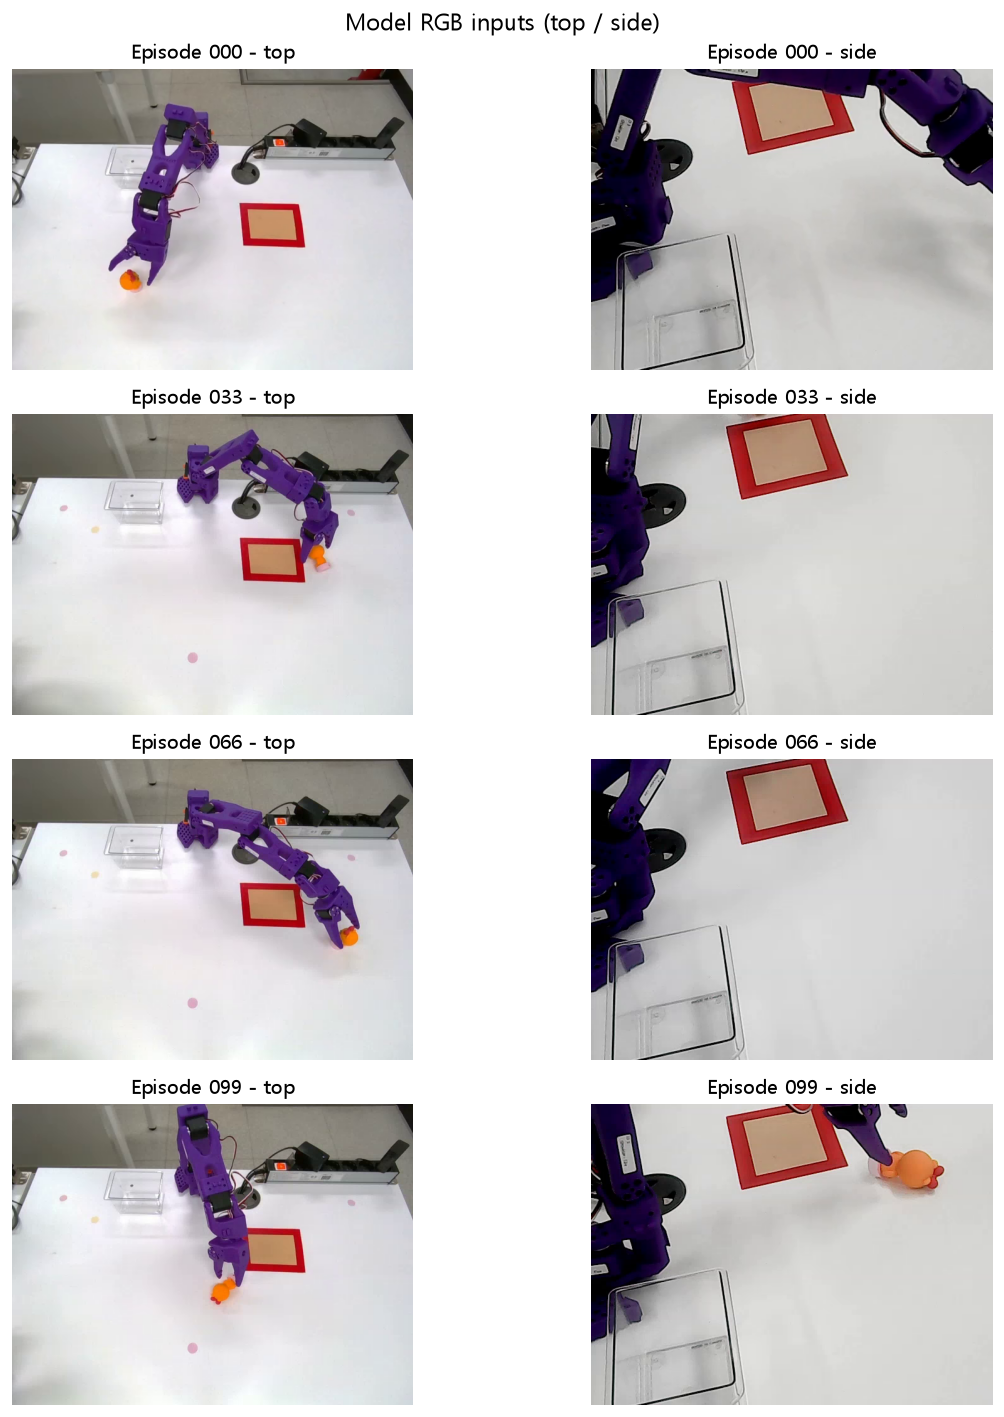

In [5]:
starts = np.asarray(dataset.meta.episodes['dataset_from_index'], dtype=int)
ends = np.asarray(dataset.meta.episodes['dataset_to_index'], dtype=int)
preview_eps = [0, 33, 66, 99]
preview_samples = []
for ep in preview_eps:
    idx = int(starts[ep] + 0.35 * (ends[ep] - starts[ep] - 1))
    preview_samples.append(dataset[idx])

fig, axes = plt.subplots(len(preview_eps), 2, figsize=(11, 12))
for row, (ep, sample) in enumerate(zip(preview_eps, preview_samples)):
    for col, key in enumerate(['observation.images.top', 'observation.images.side']):
        image = sample[key].permute(1, 2, 0).cpu().numpy()
        axes[row, col].imshow(image)
        axes[row, col].set_title(f'Episode {ep:03d} - {key.split(".")[-1]}')
        axes[row, col].axis('off')
fig.suptitle('Model RGB inputs (top / side)', fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'camera_samples.png', bbox_inches='tight')
plt.show()

## 5. 오프라인 action-chunk 예측

12개 에피소드의 서로 다른 시점에서 100-frame(약 3.33초) action chunk를 예측합니다. 영상은 학습 때와 동일하게 `uint8 → float32 / 255` 처리한 뒤 저장된 정규화기를 적용합니다.

In [6]:
eval_eps = np.linspace(0, dataset.num_episodes - 1, 12, dtype=int)
results = []
example = None

with torch.inference_mode():
    for ep in eval_eps:
        idx = int(starts[ep] + 0.35 * (ends[ep] - starts[ep] - 1))
        sample = dataset[idx]
        model_sample = dict(sample)
        for camera_key in dataset.meta.camera_keys:
            if camera_key in model_sample and model_sample[camera_key].dtype == torch.uint8:
                model_sample[camera_key] = model_sample[camera_key].float() / 255.0
        batch = preprocess(model_sample)
        predicted = postprocess(policy.predict_action_chunk(batch))[0].cpu()
        target = sample['action'].cpu()
        valid = ~sample['action_is_pad'].cpu()
        err = predicted[valid] - target[valid]
        results.append({
            'episode': int(ep), 'dataset_index': idx, 'valid_frames': int(valid.sum()),
            'pred': predicted[valid].numpy(), 'target': target[valid].numpy(),
            'abs_err': err.abs().numpy(), 'sq_err': err.square().numpy(),
        })
        if example is None or len(results) == len(eval_eps)//2:
            example = results[-1]

all_abs = np.concatenate([r['abs_err'] for r in results])
all_sq = np.concatenate([r['sq_err'] for r in results])
all_pred = np.concatenate([r['pred'] for r in results])
all_target = np.concatenate([r['target'] for r in results])
joint_mae = all_abs.mean(axis=0)
joint_rmse = np.sqrt(all_sq.mean(axis=0))
action_min = np.asarray(dataset.meta.stats['action']['min'])
action_max = np.asarray(dataset.meta.stats['action']['max'])
action_range = np.maximum(action_max - action_min, 1e-8)
normalized_mae = joint_mae / action_range
outside = (all_pred < action_min) | (all_pred > action_max)

metrics = pd.DataFrame({
    'joint': JOINTS, 'MAE': joint_mae, 'RMSE': joint_rmse,
    'train_min': action_min, 'train_max': action_max,
    'normalized_MAE': normalized_mae,
    'outside_train_range_pct': outside.mean(axis=0) * 100,
})
metrics.to_csv(OUTPUT_DIR / 'offline_metrics.csv', index=False, encoding='utf-8-sig')
display(metrics.round(4))
print(f'전체 관절 평균 MAE: {joint_mae.mean():.4f}')
print(f'학습 범위 대비 평균 MAE: {normalized_mae.mean()*100:.2f}%')
print(f'학습 범위 밖 예측 비율: {outside.mean()*100:.3f}%')

,joint,MAE,RMSE,train_min,train_max,normalized_MAE,outside_train_range_pct
0,shoulder_pan,4.1440,5.4877,-91.8681,83.5165,0.0236,0.0000
1,shoulder_lift,7.1502,9.1236,-104.5714,89.0110,0.0369,3.6667
2,elbow_flex,6.6028,8.6123,-103.6923,104.2198,0.0318,2.7500
3,wrist_flex,4.2010,6.0346,4.3077,99.5165,0.0441,11.6667
4,wrist_roll,5.0261,8.9925,-134.1978,134.3736,0.0187,0.0000
5,gripper,2.7611,4.3841,0.0000,49.3517,0.0559,25.9167


전체 관절 평균 MAE: 4.9809

학습 범위 대비 평균 MAE: 3.52%

학습 범위 밖 예측 비율: 7.333%

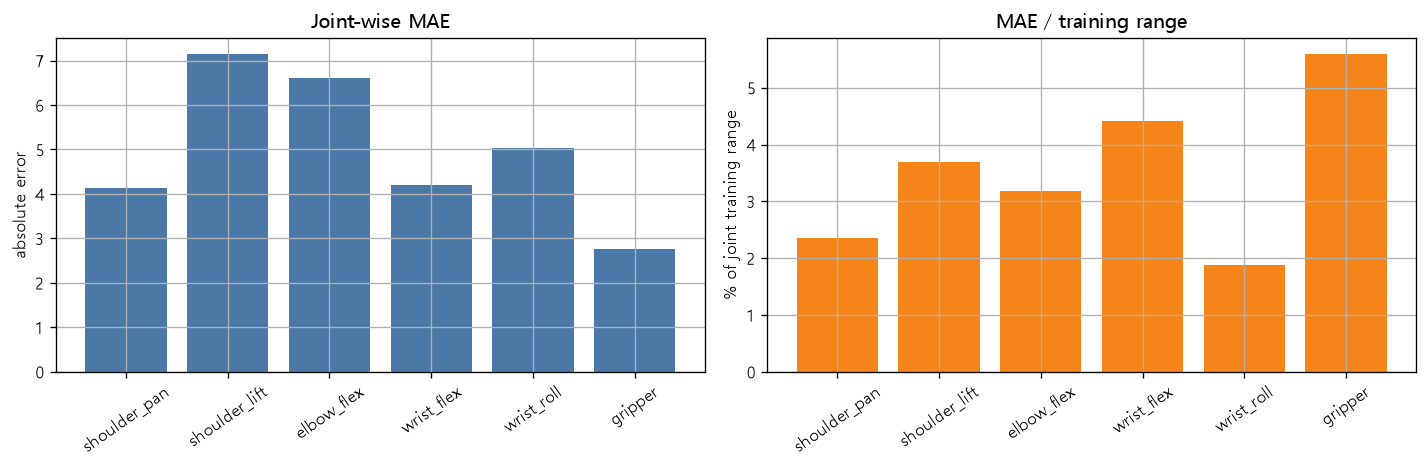

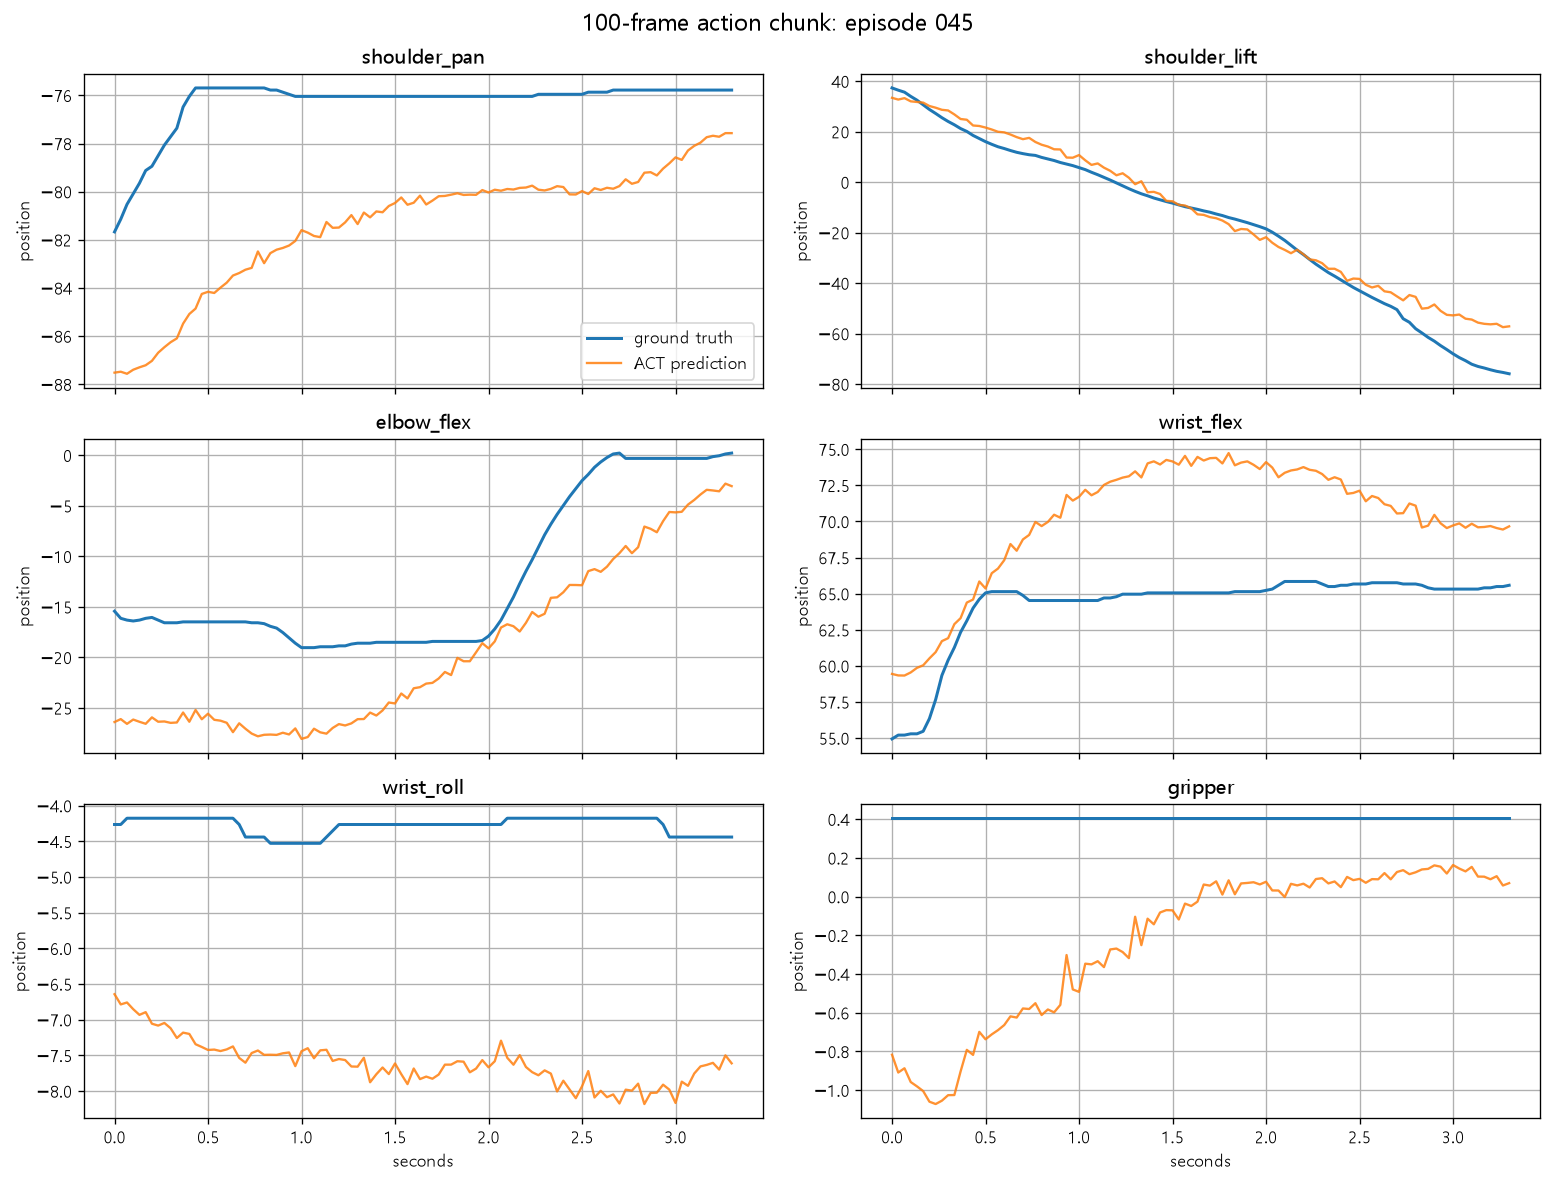

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(JOINTS, joint_mae, color='#4C78A8')
axes[0].set(title='Joint-wise MAE', ylabel='absolute error')
axes[0].tick_params(axis='x', rotation=35)
axes[1].bar(JOINTS, normalized_mae * 100, color='#F58518')
axes[1].set(title='MAE / training range', ylabel='% of joint training range')
axes[1].tick_params(axis='x', rotation=35)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'joint_errors.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
t = np.arange(example['target'].shape[0]) / dataset.fps
for j, ax in enumerate(axes.flat):
    ax.plot(t, example['target'][:, j], label='ground truth', linewidth=1.8)
    ax.plot(t, example['pred'][:, j], label='ACT prediction', linewidth=1.4, alpha=.85)
    ax.set_title(JOINTS[j])
    ax.set_ylabel('position')
    if j >= 4: ax.set_xlabel('seconds')
axes[0, 0].legend()
fig.suptitle(f"100-frame action chunk: episode {example['episode']:03d}", fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'action_chunk_comparison.png', bbox_inches='tight')
plt.show()

## 6. 자동 판정과 다음 단계

In [8]:
finite_ok = np.isfinite(all_pred).all()
curve_ok = last_window < first_window
range_ok = outside.mean() < 0.01
reconstruction_ok = normalized_mae.mean() < 0.10
checks = {
    'checkpoint_complete': bool(artifacts['exists'].all()),
    'model_and_processors_loaded': True,
    'predictions_are_finite': bool(finite_ok),
    'training_loss_improved': bool(curve_ok),
    'prediction_range_sane': bool(range_ok),
    'in_sample_reconstruction_sane': bool(reconstruction_ok),
}
verdict = 'PASS — 실제 로봇 저속·비상정지 준비 시험으로 진행 가능' if all(checks.values()) else 'REVIEW — 실제 구동 전에 아래 실패 항목 확인 필요'
summary = {
    'verdict': verdict, 'checks': checks,
    'final_logged_loss': float(train_curve.iloc[-1].loss),
    'mean_joint_mae': float(joint_mae.mean()),
    'mean_normalized_mae_pct': float(normalized_mae.mean() * 100),
    'outside_training_range_pct': float(outside.mean() * 100),
    'checkpoint': str(CHECKPOINT_DIR),
    'limitation': 'All 100 episodes were used for training; this is not a held-out generalization score.',
}
(OUTPUT_DIR / 'validation_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
display(Markdown('### ' + verdict))
display(pd.DataFrame([{'check': k, 'pass': v} for k, v in checks.items()]))
print(json.dumps(summary, ensure_ascii=False, indent=2))
display(Markdown(
    '**권장 다음 단계**\n\n'
    '1. 로봇 전원을 끈 상태에서 카메라 키·해상도·관절 순서 확인  \n'
    '2. 첫 실기에서는 action clipping, 속도 제한, 비상정지 키 적용  \n'
    '3. 학습에 쓰지 않은 시작 위치로 10~20회 성공률 측정  \n'
    '4. 다음 학습부터 episode 기준 80/20 train/validation 분리'
))

### REVIEW — 실제 구동 전에 아래 실패 항목 확인 필요

,check,pass
0,checkpoint_complete,True
1,model_and_processors_loaded,True
2,predictions_are_finite,True
3,training_loss_improved,True
4,prediction_range_sane,False
5,in_sample_reconstruction_sane,True


{
  "verdict": "REVIEW — 실제 구동 전에 아래 실패 항목 확인 필요",
  "checks": {
    "checkpoint_complete": true,
    "model_and_processors_loaded": true,
    "predictions_are_finite": true,
    "training_loss_improved": true,
    "prediction_range_sane": false,
    "in_sample_reconstruction_sane": true
  },
  "final_logged_loss": 0.198,
  "mean_joint_mae": 4.980861186981201,
  "mean_normalized_mae_pct": 3.518465531058484,
  "outside_training_range_pct": 7.333333333333333,
  "checkpoint": "D:\\lerobot-2026\\episode_sample_dataset\\doll_pickplace_act\\outputs\\act_100ep_20k\\checkpoints\\020000",
  "limitation": "All 100 episodes were used for training; this is not a held-out generalization score."
}

**권장 다음 단계**

1. 로봇 전원을 끈 상태에서 카메라 키·해상도·관절 순서 확인  
2. 첫 실기에서는 action clipping, 속도 제한, 비상정지 키 적용  
3. 학습에 쓰지 않은 시작 위치로 10~20회 성공률 측정  
4. 다음 학습부터 episode 기준 80/20 train/validation 분리